In [36]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import itertools as itt

import tqdm.auto as tqdm
from scipy.stats import pearsonr, spearmanr, kendalltau

from dti import data
from dti.constants import SMILES, ASSAY, ACT

sns.set_context("talk")

In [4]:
data_path = Path("..") / "data" / "raw"

In [5]:
df = data.load_kinodata(data_path / "activities-chembl33_v0.5.csv")

In [59]:
xs = list()
ys = list()
for _, g in tqdm.tqdm(df.groupby(SMILES)):
    if len(g) == 1:
        continue
    for x, y in itt.combinations(g[[ASSAY, ACT]].groupby(ASSAY).agg("mean")[ACT], 2):
        xs.append(x)
        ys.append(y)

  0%|          | 0/115357 [00:00<?, ?it/s]

In [60]:
xs = np.array(xs)
ys = np.array(ys)

In [71]:
mae = np.abs(xs - ys).mean()
pr = pearsonr(xs, ys).statistic
kt = kendalltau(xs, ys).statistic
sr = spearmanr(xs, ys).statistic
print(f"R2={pr:.2f}\nMAE={mae:.2f}\nKendall's tau={kt:.2f}")

R2=0.53
MAE=0.96
Kendall's tau=0.37


In [65]:
np.random.seed(0)
idcs = np.random.choice(np.arange(len(xs)), 10000)

Text(0.5, 1.0, 'IC50 agreement (kinodata)')

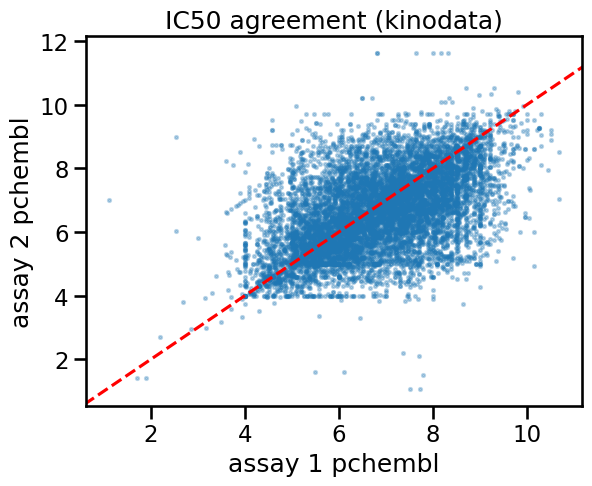

In [69]:
plt.scatter(xs[idcs], ys[idcs], s=5, alpha=0.3)
plt.xlabel("assay 1 pchembl")
plt.ylabel("assay 2 pchembl")
xl = plt.xlim()
yl = plt.ylim()
plt.plot([0, 15], [0, 15], "r--")
plt.xlim(*xl)
plt.ylim(*yl)
plt.title("IC50 agreement (kinodata)")